In [131]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.api import AMReXDataset
import matplotlib.pyplot as plt
import numpy as np
yt.set_log_level(0)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

Let's examine some outputs.

plt dir contain are snapshots of the fields on grids at various timesteps, and particle0 files. These are AMReXDatasets. 

particles files contain particle positions, velocities, and electric field at those points. These are ascii files. 

In [132]:
#dir(yt)

In [133]:
ds = AMReXDataset("plt00010")

In [134]:
#ds.field_list

In [142]:
x = []
y = []
phi = []
U = []
K=[]
start = 0
stop = 100
step = 10

for step in range(start, stop, step):
    # for each 
    ds = AMReXDataset(f"plt{step:05d}")
    
    x.append(ds.r[("all", "particle_position_x")][:])
    y.append(ds.r[("all", "particle_position_y")][:])

    U.append(np.sum(np.sqrt(ds.r[("all", "particle_Ex")][:]**2 +ds.r[("all", "particle_Ey")][:]**2+ds.r[("all", "particle_Ez")][:]**2)))
    K.append(np.sum(np.sqrt(ds.r[("all", "particle_vx")][:]**2 +ds.r[("all", "particle_vy")][:]**2+ds.r[("all", "particle_vz")][:]**2)))
   
    cg = ds.covering_grid(
        level=0,
        left_edge=ds.domain_left_edge,
        dims=ds.domain_dimensions
    )
    
    phi.append(np.asarray(cg[("boxlib", "phi")]))

#plt.scatter(x[0],y[0])

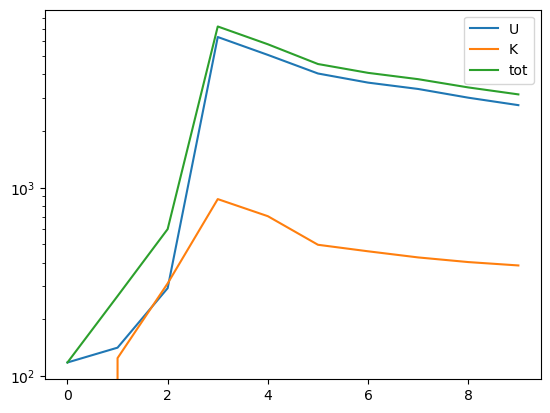

In [150]:
plt.semilogy(np.array(U), label='U')
plt.semilogy(np.array(K), label='K')

plt.semilogy(np.array(U)+np.array(K), label='tot')
plt.legend()


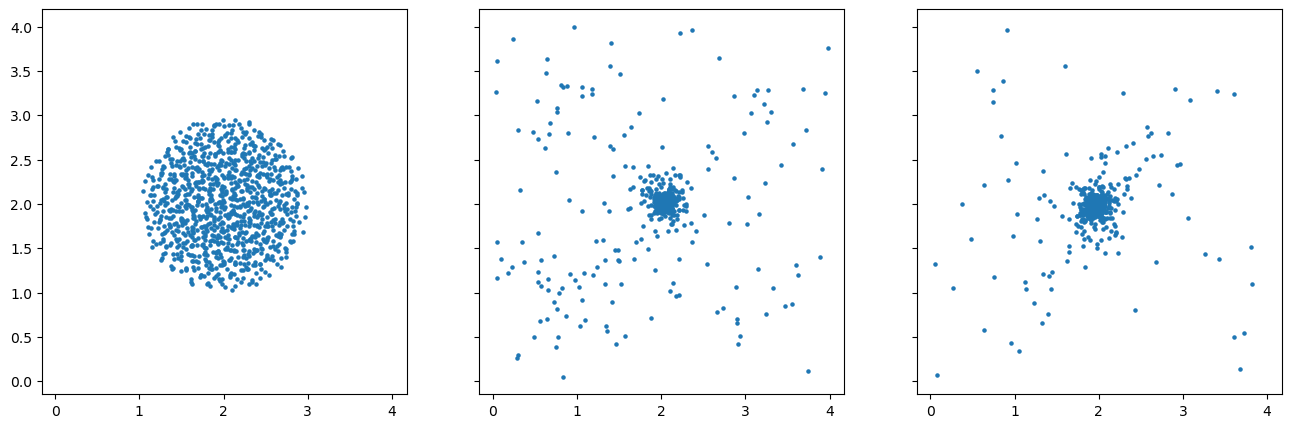

In [145]:
fig,ax = plt.subplots(1,3, figsize=(16,5), sharex=True, sharey=True)

ax[0].scatter(x[0], y[0], s=5)
ax[1].scatter(x[4], y[4], s=5)
ax[2].scatter(x[9], y[9], s=5)

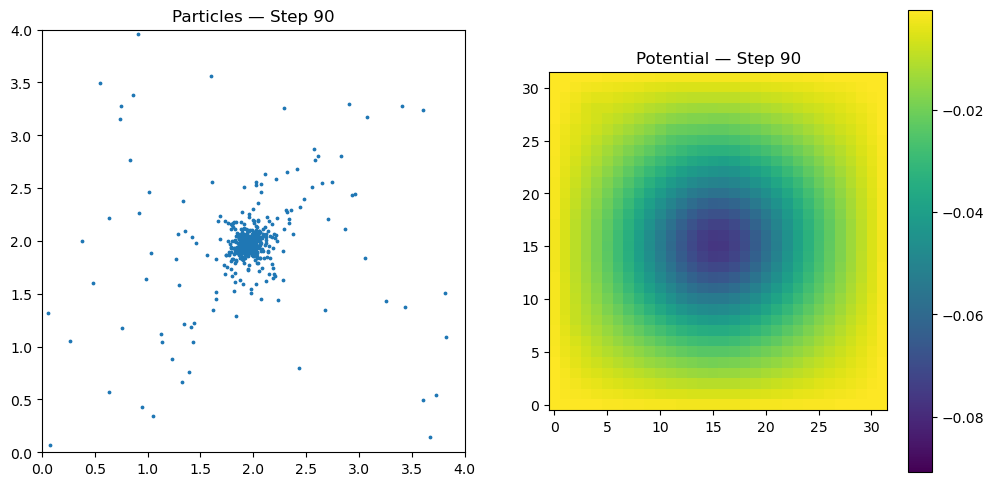

In [146]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
boxsize=4
#particle positions
ax[0].set_xlim(0,boxsize)
ax[0].set_ylim(0,boxsize)
ax[0].set_aspect("equal")
ax[0].set_title("Particles")

scat = ax[0].scatter(x[0], y[0], s=3)

# phi

# Fixed color scale for all frames
finite_phi = np.concatenate([
    p[np.isfinite(p)].ravel()
    for p in phi
])

vmin, vmax = np.percentile(finite_phi, [5, 95])
#vmax = np.max(np.abs(finite_phi))/4
#vmin = -vmax/4
#
im = ax[1].imshow(
    phi[0][:,:,8],
    origin="lower",
    aspect="equal",
    vmin=vmin,
    vmax=vmax
)

ax[1].set_title("Potential")
fig.colorbar(im, ax=ax[1])

#animate them
def update(frame):

    scat.set_offsets(
        np.column_stack((x[frame], y[frame]))
    )

    im.set_data(phi[frame][:,:,8])

    ax[0].set_title(f"Particles — Step {frame * 10}")
    ax[1].set_title(f"Potential — Step {frame * 10}")

    return scat, im

ani = FuncAnimation(
    fig, 
    update,
    frames=len(x),
    interval=500,
    blit=True
)

HTML(ani.to_jshtml())